*italicized text*## 1. <font color = red> Install and Import the Required Libraries

1.   List item
2.   List item



In [96]:
# Import required libraries

import numpy as np
import pandas as pd
import ast
import pdfplumber
from pathlib import Path
import pandas as pd
from operator import itemgetter
import json
import tiktoken
import groq
import chromadb

In [97]:
#Read the insurance doc file
input_path = '/Users/kandarp.joshi/Library/CloudStorage/OneDrive-ServiceNow/Prd/Prd/UpGrad/C6/M12/'
pdf_path = '/Users/kandarp.joshi/Library/CloudStorage/OneDrive-ServiceNow/Prd/Prd/UpGrad/C6/M12/Principal-Sample-Life-Insurance-Policy.pdf'

In [98]:
# Open the PDF file
with pdfplumber.open(pdf_path) as pdf:

    # Get one of the pages from the PDF and examine it
    single_page = pdf.pages[4]

    # Extract text from the first page
    text = single_page.extract_text()

    # Extract tables from the first page
    tables = single_page.extract_tables()

    # Print the extracted text
    print(text)

PRINCIPAL LIFE INSURANCE COMPANY
(called The Principal in this Group Policy)
Des Moines, Iowa 50392-0002
This group insurance policy is issued to:
RHODE ISLAND JOHN DOE
(called the Policyholder in this Group Policy)
The Date of Issue is November 1, 2007.
In return for the Policyholder's application and payment of all premiums when due, The Principal
agrees to provide:
MEMBER LIFE INSURANCE
MEMBER ACCIDENTAL DEATH AND DISMEMBERMENT INSURANCE
DEPENDENT LIFE INSURANCE
subject to the terms and conditions described in this Group Policy.
GROUP POLICY NO. GL S655
RENEWABLE TERM - NON-PARTICIPATING
CONTRACT STATE OF ISSUE: RHODE ISLAND
This policy has been updated effective January 1, 2014
GC 6000 TITLE PAGE


In [99]:
# Function to check whether a word is present in a table or not for segregation of regular text and tables

def check_bboxes(word, table_bbox):
    # Check whether word is inside a table bbox.
    l = word['x0'], word['top'], word['x1'], word['bottom']
    r = table_bbox
    return l[0] > r[0] and l[1] > r[1] and l[2] < r[2] and l[3] < r[3]

In [131]:
# Function to extract text from a PDF file.
# 1. Declare a variable p to store the iteration of the loop that will help us store page numbers alongside the text
# 2. Declare an empty list 'full_text' to store all the text files
# 3. Use pdfplumber to open the pdf pages one by one
# 4. Find the tables and their locations in the page
# 5. Extract the text from the tables in the variable 'tables'
# 6. Extract the regular words by calling the function check_bboxes() and checking whether words are present in the table or not
# 7. Use the cluster_objects utility to cluster non-table and table words together so that they retain the same chronology as in the original PDF
# 8. Declare an empty list 'lines' to store the page text
# 9. If a text element in present in the cluster, append it to 'lines', else if a table element is present, append the table
# 10. Append the page number and all lines to full_text, and increment 'p'
# 11. When the function has iterated over all pages, return the 'full_text' list

def extract_text_from_pdf(pdf_path):
    p = 0
    full_text = []


    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            page_no = f"Page {p+1}"
            text = page.extract_text()

            tables = page.find_tables()
            table_bboxes = [i.bbox for i in tables]
            tables = [{'table': i.extract(), 'top': i.bbox[1]} for i in tables]
            non_table_words = [word for word in page.extract_words() if not any(
                [check_bboxes(word, table_bbox) for table_bbox in table_bboxes])]
            lines = []

            for cluster in pdfplumber.utils.cluster_objects(non_table_words + tables, itemgetter('top'), tolerance=5):

                if 'text' in cluster[0]:
                    try:
                        lines.append(' '.join([i['text'] for i in cluster]))
                    except KeyError:
                        pass

                elif 'table' in cluster[0]:
                    lines.append(json.dumps(cluster[0]['table']))


            full_text.append([page_no, " ".join(lines)])
            p +=1

    return full_text

In [132]:
# Define the directory containing the PDF files
pdf_directory = Path(input_path)

# Initialize an empty list to store the extracted texts and document names
data = []

# Loop through all files in the directory
for pdf_path in pdf_directory.glob("*.pdf"):

    # Process the PDF file
    print(f"...Processing {pdf_path.name}")

    # Call the function to extract the text from the PDF
    extracted_text = extract_text_from_pdf(pdf_path)

    # Convert the extracted list to a PDF, and add a column to store document names
    extracted_text_df = pd.DataFrame(extracted_text, columns=['Page No.', 'Page_Text'])
    extracted_text_df['Document Name'] = pdf_path.name

    # Append the extracted text and document name to the list
    data.append(extracted_text_df)

    # Print a message to indicate progress
    print(f"Finished processing {pdf_path.name}")

# Print a message to indicate all PDFs have been processed
print("All PDFs have been processed.")

...Processing Principal-Sample-Life-Insurance-Policy.pdf
Finished processing Principal-Sample-Life-Insurance-Policy.pdf
All PDFs have been processed.


In [133]:
insurance_pdfs_data = pd.concat(data, ignore_index=True)
insurance_pdfs_data

,Page No.,Page_Text,Document Name
0,Page 1,DOROTHEA GLAUSE S655 RHODE ISLAND JOHN DOE 01/...,Principal-Sample-Life-Insurance-Policy.pdf
1,Page 2,This page left blank intentionally,Principal-Sample-Life-Insurance-Policy.pdf
2,Page 3,POLICY RIDER GROUP INSURANCE POLICY NO: S655 C...,Principal-Sample-Life-Insurance-Policy.pdf
3,Page 4,This page left blank intentionally,Principal-Sample-Life-Insurance-Policy.pdf
4,Page 5,PRINCIPAL LIFE INSURANCE COMPANY (called The P...,Principal-Sample-Life-Insurance-Policy.pdf
...,...,...,...
59,Page 60,I f a Dependent who was insured dies during th...,Principal-Sample-Life-Insurance-Policy.pdf
60,Page 61,Section D - Claim Procedures Article 1 - Notic...,Principal-Sample-Life-Insurance-Policy.pdf
61,Page 62,A claimant may request an appeal of a claim de...,Principal-Sample-Life-Insurance-Policy.pdf
62,Page 63,This page left blank intentionally,Principal-Sample-Life-Insurance-Policy.pdf


In [134]:
# Function 1: Fixed-size chunking with overlap
def chunk_text_with_overlap(text, chunk_size=400, overlap=50):
    """
    Split text into overlapping chunks
    Args:
        text: Input text to chunk
        chunk_size: Number of words per chunk
        overlap: Number of overlapping words between chunks
    """
    words = text.split()
    chunks = []
    
    for i in range(0, len(words), chunk_size - overlap):
        chunk = ' '.join(words[i:i + chunk_size])
        if chunk.strip():  # Only add non-empty chunks
            chunks.append(chunk)
    
    return chunks


# Function 2: Section-based chunking for insurance documents
def chunk_by_sections(text):
    """
    Split by insurance policy sections (numbered/titled sections)
    Handles patterns like: "1.", "A.", "Section 1:", "PART A", etc.
    """
    # Pattern to match section headers
    section_pattern = r'(?:^|\n)(?:\d+\.|[A-Z]\.|Section \d+:|PART [A-Z]|ANNEXURE|Clause \d+)'
    
    sections = re.split(section_pattern, text)
    sections = [s.strip() for s in sections if s.strip() and len(s.strip()) > 20]
    
    return sections


# Function 3: Hybrid chunking strategy (RECOMMENDED)
def hybrid_chunking(text, page_no, policy_name, chunk_size=400, overlap=50):
    """
    Combine section-based and fixed-size chunking with metadata
    This is the recommended approach for insurance documents
    """
    # First, try to split by sections
    sections = chunk_by_sections(text)
    
    # If no sections found, treat entire text as one section
    if not sections:
        sections = [text]
    
    chunks_with_metadata = []
    
    for section_idx, section in enumerate(sections):
        word_count = len(section.split())
        
        # If section is too large, split it further
        if word_count > chunk_size:
            sub_chunks = chunk_text_with_overlap(section, chunk_size, overlap)
            
            for sub_idx, sub_chunk in enumerate(sub_chunks):
                chunk_data = {
                    'Chunk_Text': sub_chunk,
                    'Page_No': page_no,
                    'Policy_Name': policy_name,
                    'Chunk_ID': f"P{page_no}_S{section_idx}_C{sub_idx}",
                    'Word_Count': len(sub_chunk.split()),
                    'Chunk_Type': 'section_split'
                }
                chunks_with_metadata.append(chunk_data)
        else:
            # Keep section as is
            chunk_data = {
                'Chunk_Text': section,
                'Page_No': page_no,
                'Policy_Name': policy_name,
                'Chunk_ID': f"P{page_no}_S{section_idx}",
                'Word_Count': word_count,
                'Chunk_Type': 'full_section'
            }
            chunks_with_metadata.append(chunk_data)
    
    return chunks_with_metadata


# Function 4: Apply chunking to entire dataframe
def apply_hybrid_chunking_to_df(insurance_pdfs_data):
    """
    Apply hybrid chunking to the entire insurance dataframe
    """
    all_chunks = []
    
    for idx, row in insurance_pdfs_data.iterrows():
        chunks = hybrid_chunking(
            text=row['Page_Text'],
            page_no=row['Page No.'],
            policy_name=row['Document Name'][:-4] if 'Document Name' in row else 'Unknown',
            chunk_size=400,
            overlap=50
        )
        all_chunks.extend(chunks)
    
    chunks_df = pd.DataFrame(all_chunks)
    
    print(f"Original pages: {len(insurance_pdfs_data)}")
    print(f"Total chunks created: {len(chunks_df)}")
    print(f"Average chunk size: {chunks_df['Word_Count'].mean():.1f} words")
    print(f"\nChunk type distribution:")
    print(chunks_df['Chunk_Type'].value_counts())
    
    return chunks_df

In [123]:
# Custom embedding function using multi-qa-mpnet-base-dot-v1
# This model is specifically trained for Q&A tasks
class InsuranceQAEmbedding(EmbeddingFunction):
    
    def __init__(self, model_name='multi-qa-mpnet-base-dot-v1'):
        print(f"Loading embedding model: {model_name}")
        self.model = SentenceTransformer(model_name)
        print(f"Model loaded. Embedding dimension: {self.model.get_sentence_embedding_dimension()}")
    
    def __call__(self, input: List[str]) -> List[List[float]]:
    
        # Generate embeddings for input texts
    
        embeddings = self.model.encode(
            input, 
            show_progress_bar=False,
            convert_to_numpy=True
        )
        return embeddings.tolist()


# Initialize the embedding function
embedding_function = InsuranceQAEmbedding()

Loading embedding model: multi-qa-mpnet-base-dot-v1
Model loaded. Embedding dimension: 768


In [135]:
# Apply hybrid chunking to your insurance data
print("Applying hybrid chunking strategy...")
insurance_chunks_df = apply_hybrid_chunking_to_df(insurance_pdfs_data)

# Display sample chunks
print("\n" + "="*100)
print("Sample chunks:")
print("="*100)
display(insurance_chunks_df.head(3))

Applying hybrid chunking strategy...
Original pages: 64
Total chunks created: 72
Average chunk size: 239.8 words

Chunk type distribution:
Chunk_Type
full_section     56
section_split    16
Name: count, dtype: int64

Sample chunks:


,Chunk_Text,Page_No,Policy_Name,Chunk_ID,Word_Count,Chunk_Type
0,DOROTHEA GLAUSE S655 RHODE ISLAND JOHN DOE 01/...,Page 1,Principal-Sample-Life-Insurance-Policy,PPage 1_S0,30,full_section
1,This page left blank intentionally,Page 2,Principal-Sample-Life-Insurance-Policy,PPage 2_S0,5,full_section
2,POLICY RIDER GROUP INSURANCE POLICY NO: S655 C...,Page 3,Principal-Sample-Life-Insurance-Policy,PPage 3_S0,230,full_section


In [136]:
# First, check what columns you have
print("Available columns in insurance_pdfs_data:")
print(insurance_chunks_df.columns.tolist())

Available columns in insurance_pdfs_data:
['Chunk_Text', 'Page_No', 'Policy_Name', 'Chunk_ID', 'Word_Count', 'Chunk_Type']


In [ ]:
insurance_pdfs_data.head(5)

,Page No.,Page_Text,Document Name
0,Page 1,DOROTHEA GLAUSE S655 RHODE ISLAND JOHN DOE 01/...,Principal-Sample-Life-Insurance-Policy.pdf
1,Page 2,This page left blank intentionally,Principal-Sample-Life-Insurance-Policy.pdf
2,Page 3,POLICY RIDER GROUP INSURANCE POLICY NO: S655 C...,Principal-Sample-Life-Insurance-Policy.pdf
3,Page 4,This page left blank intentionally,Principal-Sample-Life-Insurance-Policy.pdf
4,Page 5,PRINCIPAL LIFE INSURANCE COMPANY (called The P...,Principal-Sample-Life-Insurance-Policy.pdf


In [139]:
# Retain only the rows with a text length of at least 10

insurance_chunks_df = insurance_chunks_df.loc[insurance_chunks_df['Word_Count'] >= 10]
# Sort by text_length from high to low
insurance_chunks_df = insurance_chunks_df.sort_values(by='Word_Count', ascending=False)
insurance_chunks_df

,Chunk_Text,Page_No,Policy_Name,Chunk_ID,Word_Count,Chunk_Type
36,a . In no event will Dependent Life Insurance ...,Page 33,Principal-Sample-Life-Insurance-Policy,PPage 33_S0_C0,400,section_split
52,c . If a beneficiary dies at the same time or ...,Page 48,Principal-Sample-Life-Insurance-Policy,PPage 48_S0_C0,400,section_split
30,"(6) If, on the date a Member becomes eligible ...",Page 30,Principal-Sample-Life-Insurance-Policy,PPage 30_S0_C0,400,section_split
32,Scheduled Benefit in force for the Member befo...,Page 31,Principal-Sample-Life-Insurance-Policy,PPage 31_S0_C0,400,section_split
34,(1) marriage or establishment of a Civil Union...,Page 32,Principal-Sample-Life-Insurance-Policy,PPage 32_S0_C0,400,section_split
...,...,...,...,...,...,...
68,"In actual practice, benefits under this Group ...",Page 61,Principal-Sample-Life-Insurance-Policy,PPage 61_S0_C1,68,section_split
56,"given as soon as reasonably possible. Further,...",Page 50,Principal-Sample-Life-Insurance-Policy,PPage 50_S0_C1,64,section_split
29,"If a Member elects to terminate insurance and,...",Page 29,Principal-Sample-Life-Insurance-Policy,PPage 29_S0_C1,58,section_split
14,A record which is on or transmitted by paper o...,Page 15,Principal-Sample-Life-Insurance-Policy,PPage 15_S0,36,full_section


In [140]:
# Store the metadata for each page in a separate column

#insurance_pdfs_data.loc[:, 'Metadata'] = insurance_pdfs_data.apply(lambda x: {'Policy_Name': x['Document Name'][:-4], 'Page_No.': x['Page No.']}, axis=1)
#insurance_pdfs_data.head(5)

insurance_chunks_df.loc[:, 'Metadata'] = insurance_chunks_df.apply(lambda x: {'Policy_Name': x['Policy_Name'][:-4], 'Page_No.': x['Page_No']}, axis=1)
insurance_chunks_df.head(5)

,Chunk_Text,Page_No,Policy_Name,Chunk_ID,Word_Count,Chunk_Type,Metadata
36,a . In no event will Dependent Life Insurance ...,Page 33,Principal-Sample-Life-Insurance-Policy,PPage 33_S0_C0,400,section_split,{'Policy_Name': 'Principal-Sample-Life-Insuran...
52,c . If a beneficiary dies at the same time or ...,Page 48,Principal-Sample-Life-Insurance-Policy,PPage 48_S0_C0,400,section_split,{'Policy_Name': 'Principal-Sample-Life-Insuran...
30,"(6) If, on the date a Member becomes eligible ...",Page 30,Principal-Sample-Life-Insurance-Policy,PPage 30_S0_C0,400,section_split,{'Policy_Name': 'Principal-Sample-Life-Insuran...
32,Scheduled Benefit in force for the Member befo...,Page 31,Principal-Sample-Life-Insurance-Policy,PPage 31_S0_C0,400,section_split,{'Policy_Name': 'Principal-Sample-Life-Insuran...
34,(1) marriage or establishment of a Civil Union...,Page 32,Principal-Sample-Life-Insurance-Policy,PPage 32_S0_C0,400,section_split,{'Policy_Name': 'Principal-Sample-Life-Insuran...


Above steps concludes the chunking aspect, as we can see that mostly the pages contain few hundred words, maximum going upto 462. So, we don't need to chunk the documents further; we can perform the embeddings on individual pages. This strategy makes sense for 2 reasons:
1. The way insurance documents are generally structured, you will not have a lot of extraneous information in a page, and all the text pieces in that page will likely be interrelated.
2. We want to have larger chunk sizes to be able to pass appropriate context to the LLM during the generation layer.

## STEP 2 . <font color = red> Embedding via CHROMADB </font>

In [141]:
# Create metadata for each chunk
insurance_chunks_df['Metadata'] = insurance_chunks_df.apply(
    lambda x: {
        'Policy_Name': x['Policy_Name'],
        'Page_No': str(x['Page_No']),
        'Chunk_ID': x['Chunk_ID'],
        'Word_Count': x['Word_Count'],
        'Chunk_Type': x['Chunk_Type']
    }, 
    axis=1
)

# Prepare data for ChromaDB
documents_list = insurance_chunks_df['Chunk_Text'].tolist()
metadata_list = insurance_chunks_df['Metadata'].tolist()
ids_list = insurance_chunks_df['Chunk_ID'].tolist()

print(f"\nPrepared {len(documents_list)} chunks for embedding")
print(f"Sample metadata: {metadata_list[0]}")


Prepared 68 chunks for embedding
Sample metadata: {'Policy_Name': 'Principal-Sample-Life-Insurance-Policy', 'Page_No': 'Page 33', 'Chunk_ID': 'PPage 33_S0_C0', 'Word_Count': 400, 'Chunk_Type': 'section_split'}


In [142]:
import chromadb 
client = chromadb.Client()
client = chromadb.PersistentClient(path = input_path)


In [143]:
import chromadb

# Initialize ChromaDB client
client = chromadb.PersistentClient()

# Delete old collection if it exists (optional)
try:
    client.delete_collection(name='RAG_on_Insurance')
    print("Deleted old collection")
except:
    print("No existing collection to delete")

# Create new collection with improved embeddings
insurance_collection = client.get_or_create_collection(
    name='RAG_on_Insurance',
    embedding_function=embedding_function,
    metadata={"description": "Insurance policy documents with hybrid chunking and Q&A optimized embeddings"}
)

print(f"\nCollection created: {insurance_collection.name}")
print(f"Embedding function: multi-qa-mpnet-base-dot-v1")

Deleted old collection

Collection created: RAG_on_Insurance
Embedding function: multi-qa-mpnet-base-dot-v1


In [144]:
# Add documents in batches to avoid memory issues
batch_size = 100
total_batches = (len(documents_list) + batch_size - 1) // batch_size

print(f"Adding {len(documents_list)} documents in {total_batches} batches...")

for i in range(0, len(documents_list), batch_size):
    batch_docs = documents_list[i:i+batch_size]
    batch_ids = ids_list[i:i+batch_size]
    batch_metadata = metadata_list[i:i+batch_size]
    
    insurance_collection.add(
        documents=batch_docs,
        ids=batch_ids,
        metadatas=batch_metadata
    )
    
    print(f"Batch {i//batch_size + 1}/{total_batches} added")

print(f"\n✓ Successfully added {insurance_collection.count()} documents to collection")

Adding 68 documents in 1 batches...
Batch 1/1 added

✓ Successfully added 68 documents to collection


In [145]:
# Test query
test_query = "What are the exclusions in this policy?"

print(f"Test Query: {test_query}")
print("="*100)

# Query the collection
results = insurance_collection.query(
    query_texts=[test_query],
    n_results=5
)

# Display results
print("\nTop 5 Results:")
print("="*100)

for i in range(len(results['documents'][0])):
    print(f"\n[Result {i+1}]")
    print(f"Chunk ID: {results['ids'][0][i]}")
    print(f"Distance: {results['distances'][0][i]:.4f}")
    print(f"Metadata: {results['metadatas'][0][i]}")
    print(f"\nContent:")
    print(textwrap.fill(results['documents'][0][i], width=100))
    print("-"*100)

Test Query: What are the exclusions in this policy?

Top 5 Results:

[Result 1]
Chunk ID: PPage 6_S0
Distance: 37.3358
Metadata: {'Policy_Name': 'Principal-Sample-Life-Insurance-Policy', 'Chunk_ID': 'PPage 6_S0', 'Word_Count': 153, 'Page_No': 'Page 6', 'Chunk_Type': 'full_section'}

Content:
TABLE OF CONTENTS PART I - DEFINITIONS PART II - POLICY ADMINISTRATION Section A – Contract Entire
Contract Article 1 Policy Changes Article 2 Policyholder Eligibility Requirements Article 3 Policy
Incontestability Article 4 Individual Incontestability Article 5 Information to be Furnished Article
6 Certificates Article 7 Assignments Article 8 Dependent Rights Article 9 Policy Interpretation
Article 10 Electronic Transactions Article 11 Section B – Premium Payment Responsibility; Due Dates;
Grace Period Article 1 Premium Rates Article 2 Premium Rate Changes Article 3 Premium Amount Article
4 Contributions from Members Article 5 Section C - Policy Termination Failure to Pay Premium Article
1 Termina

In [ ]:
# Function to compare chunking strategies
def compare_retrieval_quality(query, collection_new, collection_old=None):
    
    print(f"Query: {query}")
    print("="*100)
    
    # New approach results
    results_new = collection_new.query(query_texts=[query], n_results=3)
    
    print("\n🆕 NEW APPROACH (Hybrid Chunking + Multi-QA-MPNet):")
    print("-"*100)
    for i in range(len(results_new['documents'][0])):
        print(f"\n[{i+1}] Distance: {results_new['distances'][0][i]:.4f}")
        print(f"Chunk: {results_new['ids'][0][i]}")
        print(textwrap.fill(results_new['documents'][0][i][:200] + "...", width=100))
    
    # If you have old collection, compare
    if collection_old:
        results_old = collection_old.query(query_texts=[query], n_results=3)
        print("\n\n📊 OLD APPROACH (Page-based + MiniLM):")
        print("-"*100)
        for i in range(len(results_old['documents'][0])):
            print(f"\n[{i+1}] Distance: {results_old['distances'][0][i]:.4f}")
            print(textwrap.fill(results_old['documents'][0][i][:200] + "...", width=100))

# Test with sample queries
test_queries = [
    "What is covered under this policy?",
    "What are the exclusions?",
    "How do I file a claim?",
    "What is the premium amount?"
]

for query in test_queries:
    compare_retrieval_quality(query, insurance_collection)
    print("\n" + "="*100 + "\n")

Query: What is covered under this policy?

🆕 NEW APPROACH (Hybrid Chunking + Multi-QA-MPNet):
----------------------------------------------------------------------------------------------------

[1] Distance: 32.1272
Chunk: PPage 6_S0
TABLE OF CONTENTS PART I - DEFINITIONS PART II - POLICY ADMINISTRATION Section A – Contract Entire
Contract Article 1 Policy Changes Article 2 Policyholder Eligibility Requirements Article 3 Policy
In...

[2] Distance: 32.2131
Chunk: PPage 16_S0
I - POLICY ADMINISTRATION Section A - Contract Article 1 - Entire Contract This Group Policy, the
current Certificate, the attached Policyholder application, and any Member applications make up the
en...

[3] Distance: 32.2205
Chunk: PPage 7_S0
Section A – Eligibility Member Life Insurance Article 1 Member Accidental Death and Dismemberment
Insurance Article 2 Dependent Life Insurance Article 3 Section B - Effective Dates Member Life
Insuran...


Query: What are the exclusions?

🆕 NEW APPROACH (Hybrid Chunking + 

In [ ]:
#insurance_pdfs_data.loc[:, 'Metadata'] = insurance_pdfs_data.apply(lambda x: {'Policy_Name': x['Document Name'][:-4], 'Page_No.': x['Page No.']}, axis=1)
#insurance_pdfs_data.head(5)

#insurance_pdfs_data.loc[:, 'Metadata'] = insurance_pdfs_data.apply(lambda x: {'Policy_Name': x['Document Name'][:-4], 'Page_No.': x['Page No.']}, axis=1)
#insurance_pdfs_data.head(5)

,Page No.,Page_Text,Document Name,Metadata
0,Page 1,DOROTHEA GLAUSE S655 RHODE ISLAND JOHN DOE 01/...,Principal-Sample-Life-Insurance-Policy.pdf,{'Policy_Name': 'Principal-Sample-Life-Insuran...
1,Page 2,This page left blank intentionally,Principal-Sample-Life-Insurance-Policy.pdf,{'Policy_Name': 'Principal-Sample-Life-Insuran...
2,Page 3,POLICY RIDER GROUP INSURANCE POLICY NO: S655 C...,Principal-Sample-Life-Insurance-Policy.pdf,{'Policy_Name': 'Principal-Sample-Life-Insuran...
3,Page 4,This page left blank intentionally,Principal-Sample-Life-Insurance-Policy.pdf,{'Policy_Name': 'Principal-Sample-Life-Insuran...
4,Page 5,PRINCIPAL LIFE INSURANCE COMPANY (called The P...,Principal-Sample-Life-Insurance-Policy.pdf,{'Policy_Name': 'Principal-Sample-Life-Insuran...


In [ ]:
# Convert the page text and metadata from your dataframe to lists to be able to pass it to chroma

#documents_list = insurance_pdfs_data["Page_Text"].tolist()
#metadata_list = insurance_pdfs_data['Metadata'].tolist()

In [154]:
# Add the documents and metadata to the collection alongwith generic integer IDs. You can also feed the metadata information as IDs by combining the policy name and page no.

insurance_collection.add(
    documents= documents_list,
    ids = [str(i) for i in range(0, len(documents_list))],
    metadatas = metadata_list
)

In [155]:
# Let's take a look at the first few entries in the collection

insurance_collection.get(
    ids = ['0','1','2'],
    include = ['embeddings', 'documents', 'metadatas']
)

{'ids': ['0', '1', '2'],
 'embeddings': array([[ 0.17551658, -0.34315574, -0.02340976, ..., -0.10116691,
         -0.04053118,  0.05488583],
        [ 0.23870157, -0.2189596 , -0.09677778, ..., -0.0425731 ,
         -0.35640571,  0.1813141 ],
        [-0.08436407, -0.13420936, -0.07752441, ...,  0.08715627,
         -0.34411684,  0.0260925 ]]),
 'documents': ["a . In no event will Dependent Life Insurance be in force for a Member who is not insured for Member Life Insurance. b. If a Dependent spouse is in a Period of Limited Activity on the date Dependent Life Insurance or an increase in Dependent Life Insurance Scheduled Benefit due to a change in the Member's Annual Compensation or insurance class would otherwise be effective, such insurance or increase will not be in force for that Dependent spouse until the Period of Limited Activity ends. However, this Period of Limited Activity requirement may be waived as described below. When insurance under this Group Policy replaces coverage 

In [156]:
cache_collection = client.get_or_create_collection(name='Insurance_Cache', embedding_function=embedding_function)

In [157]:
cache_collection.peek()

{'ids': ['What are the exclusions in the policy? '],
 'embeddings': array([[ 2.00165547e-02, -2.07828134e-01, -3.58232707e-01,
          5.81080206e-02,  3.08457259e-02, -1.71973884e-01,
          2.74180435e-02,  1.47085503e-01,  2.89003491e-01,
          1.87874138e-01,  4.48602587e-02,  7.79648572e-02,
          9.46490765e-02,  8.82148966e-02, -2.94634730e-01,
         -1.74461305e-02,  1.10609613e-01, -1.15049675e-01,
          7.88500533e-02, -2.96702713e-01, -3.88972402e-01,
          2.40493745e-01, -2.90114403e-01,  2.07089603e-01,
          3.08485720e-02, -2.04829261e-01,  2.22425669e-01,
         -2.47092247e-02, -2.10271165e-01, -2.95096487e-02,
          1.01182446e-01,  4.85575534e-02, -1.12407647e-01,
         -7.11678192e-02, -9.74159702e-05, -2.25914061e-01,
         -7.49424696e-02,  4.50615585e-02,  8.23293179e-02,
         -1.37626976e-02, -3.11999053e-01,  4.67676967e-02,
          7.45127350e-02, -2.70054191e-02,  1.29073560e-01,
          5.21078780e-02,  1.0714

## STEP 3. <font color = red> Semantic Search with Cache

In this section, we will perform a semantic search of a query in the collections embeddings to get several top semantically similar results.

In [158]:
# Read the user query

query = input()

In [159]:
# Searh the Cache collection first
# Query the collection against the user query and return the top 20 results

cache_results = cache_collection.query(
    query_texts=query,
    n_results=1
)

In [160]:
cache_results

{'ids': [['What are the exclusions in the policy? ']],
 'embeddings': None,
 'documents': [['What are the exclusions in the policy? ']],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[{'metadatas6': "{'Word_Count': 324, 'Chunk_ID': 'PPage 16_S0', 'Page_No': 'Page 16', 'Chunk_Type': 'full_section', 'Policy_Name': 'Principal-Sample-Life-Insurance-Policy'}",
    'documents1': 'TABLE OF CONTENTS PART I - DEFINITIONS PART II - POLICY ADMINISTRATION Section A – Contract Entire Contract Article 1 Policy Changes Article 2 Policyholder Eligibility Requirements Article 3 Policy Incontestability Article 4 Individual Incontestability Article 5 Information to be Furnished Article 6 Certificates Article 7 Assignments Article 8 Dependent Rights Article 9 Policy Interpretation Article 10 Electronic Transactions Article 11 Section B – Premium Payment Responsibility; Due Dates; Grace Period Article 1 Premium Rates Article 2 Premium Rate Changes Articl

In [161]:
results = insurance_collection.query(
query_texts=query,
n_results=10
)
results.items()

dict_items([('ids', [['PPage 6_S0', '50', 'PPage 7_S0', '48', 'PPage 9_S0', '10', 'PPage 16_S0', '21', 'PPage 8_S0', '49']]), ('embeddings', None), ('documents', [['TABLE OF CONTENTS PART I - DEFINITIONS PART II - POLICY ADMINISTRATION Section A – Contract Entire Contract Article 1 Policy Changes Article 2 Policyholder Eligibility Requirements Article 3 Policy Incontestability Article 4 Individual Incontestability Article 5 Information to be Furnished Article 6 Certificates Article 7 Assignments Article 8 Dependent Rights Article 9 Policy Interpretation Article 10 Electronic Transactions Article 11 Section B – Premium Payment Responsibility; Due Dates; Grace Period Article 1 Premium Rates Article 2 Premium Rate Changes Article 3 Premium Amount Article 4 Contributions from Members Article 5 Section C - Policy Termination Failure to Pay Premium Article 1 Termination Rights of the Policyholder Article 2 Termination Rights of The Principal Article 3 Policyholder Responsibility to Members A

In [162]:
# Implementing Cache in Semantic Search

# Set a threshold for cache search
threshold = 0.2

ids = []
documents = []
distances = []
metadatas = []
results_df = pd.DataFrame()


# If the distance is greater than the threshold, then return the results from the main collection.

if cache_results['distances'][0] == [] or cache_results['distances'][0][0] > threshold:
      # Query the collection against the user query and return the top 10 results
      results = insurance_collection.query(
      query_texts=query,
      n_results=10
      )

      # Store the query in cache_collection as document w.r.t to ChromaDB so that it can be embedded and searched against later
      # Store retrieved text, ids, distances and metadatas in cache_collection as metadatas, so that they can be fetched easily if a query indeed matches to a query in cache
      Keys = []
      Values = []

      for key, val in results.items():
        if val is None:
          continue
        for i in range(min(10, len(val[0]))):
          Keys.append(str(key)+str(i))
          Values.append(str(val[0][i]))


      cache_collection.add(
          documents= [query],
          ids = [query],  # Or if you want to assign integers as IDs 0,1,2,.., then you can use "len(cache_results['documents'])" as will return the no. of queries currently in the cache and assign the next digit to the new query."
          metadatas = dict(zip(Keys, Values))
      )

      print("Not found in cache. Found in main collection.")

      result_dict = {'Metadatas': results['metadatas'][0], 'Documents': results['documents'][0], 'Distances': results['distances'][0], "IDs":results["ids"][0]}
      results_df = pd.DataFrame.from_dict(result_dict)
      results_df


# If the distance is, however, less than the threshold, you can return the results from cache

elif cache_results['distances'][0][0] <= threshold:
      cache_result_dict = cache_results['metadatas'][0][0]

      # Loop through each inner list and then through the dictionary
      for key, value in cache_result_dict.items():
          if 'ids' in key:
              ids.append(value)
          elif 'documents' in key:
              documents.append(value)
          elif 'distances' in key:
              distances.append(value)
          elif 'metadatas' in key:
              metadatas.append(value)

      print("Found in cache!")

      # Create a DataFrame
      results_df = pd.DataFrame({
        'IDs': ids,
        'Documents': documents,
        'Distances': distances,
        'Metadatas': metadatas
      })


Found in cache!


In [163]:
results_df

,IDs,Documents,Distances,Metadatas
0,5,TABLE OF CONTENTS PART I - DEFINITIONS PART II...,38.159385681152344,"{'Word_Count': 324, 'Chunk_ID': 'PPage 16_S0',..."
1,7,PART II - POLICY ADMINISTRATION Section A - Co...,36.16551208496094,{'Policy_Name': 'Principal-Sample-Life-Insuran...
2,PPage 6_S0,Section A – Eligibility Member Life Insurance ...,38.626548767089844,"{'Word_Count': 171, 'Chunk_ID': 'PPage 8_S0', ..."
3,PPage 9_S0,P ART I - DEFINITIONS When used in this Group ...,36.16551208496094,"{'Page_No.': 'Page 6', 'Policy_Name': 'Princip..."
4,8,TABLE OF CONTENTS PART I - DEFINITIONS PART II...,37.704200744628906,"{'Word_Count': 387, 'Chunk_Type': 'full_sectio..."
5,PPage 7_S0,Section A – Eligibility Member Life Insurance ...,35.53007125854492,"{'Page_No.': 'Page 16', 'Policy_Name': 'Princi..."
6,6,Section A - Member Life Insurance Schedule of ...,38.626548767089844,{'Policy_Name': 'Principal-Sample-Life-Insuran...
7,PPage 8_S0,I - POLICY ADMINISTRATION Section A - Contract...,38.62530517578125,"{'Page_No.': 'Page 7', 'Policy_Name': 'Princip..."
8,PPage 16_S0,Section A - Member Life Insurance Schedule of ...,37.70420837402344,"{'Chunk_Type': 'full_section', 'Word_Count': 1..."
9,15,P ART I - DEFINITIONS When used in this Group ...,35.53007125854492,"{'Chunk_Type': 'full_section', 'Chunk_ID': 'PP..."


In [164]:
cache_results = cache_collection.query(
    query_texts = query,
    n_results = 1
)
cache_results

{'ids': [['What are the exclusions in the policy? ']],
 'embeddings': None,
 'documents': [['What are the exclusions in the policy? ']],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[{'documents9': 'Section A - Member Life Insurance Schedule of Insurance Article 1 Death Benefits Payable Article 2 Beneficiary Article 3 Facility of Payment Article 4 Settlement of Proceeds Article 5 Member Life Insurance - Coverage During Disability Article 6 Accelerated Benefits Article 7 Section B - Member Accidental Death and Dismemberment Insurance Schedule of Insurance Article 1 Benefit Qualification Article 2 Benefits Payable Article 3 Seat Belt Benefit Article 4 Loss of Use or Paralysis Benefit Article 5 Loss of Speech and/or Hearing Benefit Article 6 Repatriation Benefit Article 7 Educational Benefit Article 8 Limitations Article 9 Section C - Dependent Life Insurance Schedule of Insurance Article 1 Death Benefits Payable Article 2 Beneficiary 

## 4. <font color = red> Re-Ranking with a Cross Encoder

Re-ranking the results obtained from your semantic search can sometime significantly improve the relevance of the retrieved results. This is often done by passing the query paired with each of the retrieved responses into a cross-encoder to score the relevance of the response w.r.t. the query.

<br>

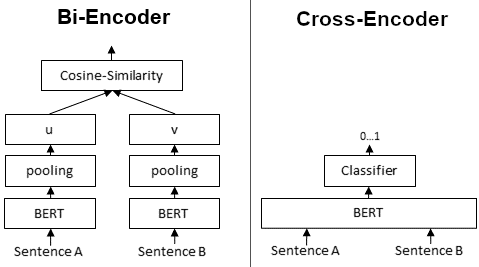

<br>

In [165]:
import pandas as pd
import numpy as np
import re
import textwrap
from sentence_transformers import SentenceTransformer
from chromadb.api.types import EmbeddingFunction
from typing import List

In [166]:
from sentence_transformers import SentenceTransformer
from chromadb.api.types import EmbeddingFunction
from typing import List

# Best embedding model for your use case
class InsuranceQAEmbedding(EmbeddingFunction):
    def __init__(self):
        self.model = SentenceTransformer('multi-qa-mpnet-base-dot-v1')
    
    def __call__(self, input: List[str]) -> List[List[float]]:
        embeddings = self.model.encode(input, show_progress_bar=False)
        return embeddings.tolist()

embedding_function = InsuranceQAEmbedding()

# Best chunking strategy
def insurance_hybrid_chunking(text, page_no, chunk_size=400, overlap=50):
    sections = chunk_by_sections(text)
    
    final_chunks = []
    for section in sections:
        if len(section.split()) > chunk_size:
            final_chunks.extend(chunk_text_with_overlap(section, chunk_size, overlap))
        else:
            final_chunks.append(section)
    
    return final_chunks

In [167]:
# Initialise the cross encoder model
from sentence_transformers import CrossEncoder

cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

In [ ]:
# Test the cross encoder model

scores = cross_encoder.predict([['What are the Policy guidelines for Loss of Use or Paralysis', 'If a Member sustains an injury, and as a result of such injury, one or more of the covered losses listed below are incurred, The Principal will pay the following percentages of the Members Scheduled Benefit (or approved amount, if applicable) in force, provided all Benefit Qualifications as described in Article 2 are met.'],
                                ['What are the Policy guidelines for Loss of Use or Paralysis', 'If death occurs while Coverage During Disability is in force, The Principal will pay the Members beneficiary the Member Life Insurance benefit amount that would have been paid had the Member remained insured under the Schedule of Insurance in force on the date Total Disability began.']])
                                

In [172]:
scores

array([-10.978429, -11.273783], dtype=float32)

In [173]:
# Input (query, response) pairs for each of the top 20 responses received from the semantic search to the cross encoder
# Generate the cross_encoder scores for these pairs

cross_inputs = [[query, response] for response in results_df['Documents']]
cross_rerank_scores = cross_encoder.predict(cross_inputs)

In [174]:
cross_rerank_scores

array([-10.357737 ,  -8.271941 , -10.542406 ,  -6.2268305, -10.357737 ,
       -10.542406 , -10.819793 ,  -8.195069 , -10.819793 ,  -6.2268305],
      dtype=float32)

In [175]:
# Store the rerank_scores in results_df

results_df['Reranked_scores'] = cross_rerank_scores 

In [176]:
results_df

,IDs,Documents,Distances,Metadatas,Reranked_scores
0,5,TABLE OF CONTENTS PART I - DEFINITIONS PART II...,38.159385681152344,"{'Word_Count': 324, 'Chunk_ID': 'PPage 16_S0',...",-10.357737
1,7,PART II - POLICY ADMINISTRATION Section A - Co...,36.16551208496094,{'Policy_Name': 'Principal-Sample-Life-Insuran...,-8.271941
2,PPage 6_S0,Section A – Eligibility Member Life Insurance ...,38.626548767089844,"{'Word_Count': 171, 'Chunk_ID': 'PPage 8_S0', ...",-10.542406
3,PPage 9_S0,P ART I - DEFINITIONS When used in this Group ...,36.16551208496094,"{'Page_No.': 'Page 6', 'Policy_Name': 'Princip...",-6.226830
4,8,TABLE OF CONTENTS PART I - DEFINITIONS PART II...,37.704200744628906,"{'Word_Count': 387, 'Chunk_Type': 'full_sectio...",-10.357737
5,PPage 7_S0,Section A – Eligibility Member Life Insurance ...,35.53007125854492,"{'Page_No.': 'Page 16', 'Policy_Name': 'Princi...",-10.542406
6,6,Section A - Member Life Insurance Schedule of ...,38.626548767089844,{'Policy_Name': 'Principal-Sample-Life-Insuran...,-10.819793
7,PPage 8_S0,I - POLICY ADMINISTRATION Section A - Contract...,38.62530517578125,"{'Page_No.': 'Page 7', 'Policy_Name': 'Princip...",-8.195069
8,PPage 16_S0,Section A - Member Life Insurance Schedule of ...,37.70420837402344,"{'Chunk_Type': 'full_section', 'Word_Count': 1...",-10.819793
9,15,P ART I - DEFINITIONS When used in this Group ...,35.53007125854492,"{'Chunk_Type': 'full_section', 'Chunk_ID': 'PP...",-6.226830


In [177]:
# Return the top 3 results from semantic search

top_3_semantic = results_df.sort_values(by='Distances')
top_3_semantic[:3]

,IDs,Documents,Distances,Metadatas,Reranked_scores
5,PPage 7_S0,Section A – Eligibility Member Life Insurance ...,35.53007125854492,"{'Page_No.': 'Page 16', 'Policy_Name': 'Princi...",-10.542406
9,15,P ART I - DEFINITIONS When used in this Group ...,35.53007125854492,"{'Chunk_Type': 'full_section', 'Chunk_ID': 'PP...",-6.226830
1,7,PART II - POLICY ADMINISTRATION Section A - Co...,36.16551208496094,{'Policy_Name': 'Principal-Sample-Life-Insuran...,-8.271941


In [178]:
# Return the top 3 results after reranking

top_3_rerank = results_df.sort_values(by='Reranked_scores', ascending=False)
top_3_rerank[:3]

,IDs,Documents,Distances,Metadatas,Reranked_scores
3,PPage 9_S0,P ART I - DEFINITIONS When used in this Group ...,36.16551208496094,"{'Page_No.': 'Page 6', 'Policy_Name': 'Princip...",-6.226830
9,15,P ART I - DEFINITIONS When used in this Group ...,35.53007125854492,"{'Chunk_Type': 'full_section', 'Chunk_ID': 'PP...",-6.226830
7,PPage 8_S0,I - POLICY ADMINISTRATION Section A - Contract...,38.62530517578125,"{'Page_No.': 'Page 7', 'Policy_Name': 'Princip...",-8.195069


In [179]:
top_3_RAG = top_3_rerank[["Documents", "Metadatas"]][:3]

In [180]:
top_3_RAG

,Documents,Metadatas
3,P ART I - DEFINITIONS When used in this Group ...,"{'Page_No.': 'Page 6', 'Policy_Name': 'Princip..."
9,P ART I - DEFINITIONS When used in this Group ...,"{'Chunk_Type': 'full_section', 'Chunk_ID': 'PP..."
7,I - POLICY ADMINISTRATION Section A - Contract...,"{'Page_No.': 'Page 7', 'Policy_Name': 'Princip..."


## 5. Retrieval Augmented Generation

Now that we have the final top search results, we can pass it to an GPT 3.5 along with the user query and a well-engineered prompt, to generate a direct answer to the query along with citations, rather than returning whole pages/chunks.

In [181]:
from groq import Groq
# Read the OpenAI API key
groq_api_key = "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"

groq_client = Groq(api_key=groq_api_key)

In [182]:
def retrieve_context(query, collection, n_results=5):
    """
    Retrieve relevant context from ChromaDB collection
    
    Args:
        query: User query string
        collection: ChromaDB collection
        n_results: Number of results to retrieve
    
    Returns:
        Dictionary with documents, metadata, and distances
    """
    results = collection.query(
        query_texts=[query],
        n_results=n_results
    )
    
    return {
        'documents': results['documents'][0],
        'metadatas': results['metadatas'][0],
        'distances': results['distances'][0],
        'ids': results['ids'][0]
    }


def format_context_for_prompt(retrieved_results):
    """
    Format retrieved documents into a structured context string
    
    Args:
        retrieved_results: Dictionary from retrieve_context()
    
    Returns:
        Formatted context string
    """
    context_parts = []
    
    for i, (doc, metadata, distance) in enumerate(zip(
        retrieved_results['documents'],
        retrieved_results['metadatas'],
        retrieved_results['distances']
    ), 1):
        context_part = f"""
[Document {i}]
Policy: {metadata.get('Policy_Name', 'Unknown')}
Page: {metadata.get('Page_No', 'Unknown')}
Chunk ID: {metadata.get('Chunk_ID', 'Unknown')}
Relevance Score: {1 - distance:.3f}

Content:
{doc}

---
"""
        context_parts.append(context_part)
    
    return "\n".join(context_parts)


def create_rag_prompt(query, context):
    """
    Create a comprehensive RAG prompt for the LLM
    
    Args:
        query: User query
        context: Formatted context from retrieved documents
    
    Returns:
        List of messages for chat completion
    """
    system_prompt = """You are an expert insurance policy assistant. Your role is to provide accurate, helpful answers about insurance policies based on the provided context.

Guidelines:
1. Answer questions directly and concisely
2. Use ONLY information from the provided context
3. If the context doesn't contain enough information, say so clearly
4. Cite specific policy names and page numbers when providing information
5. For numerical information (premiums, coverage amounts, etc.), provide exact figures from the context
6. If you find conflicting information, mention it
7. Use clear, customer-friendly language
8. Structure your response with bullet points or sections when appropriate
9. Always provide citations at the end in the format: [Policy Name, Page X]"""

    user_prompt = f"""Based on the following context from insurance policy documents, please answer the user's question.

CONTEXT:
{context}

USER QUESTION:
{query}

Please provide a comprehensive answer with citations."""

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
    
    return messages


def generate_response_with_groq(messages, model="llama-3.3-70b-versatile", temperature=0.3, max_tokens=1024):
    """
    Generate response using Groq
    
    Args:
        messages: List of message dictionaries
        model: Groq model name
        temperature: Sampling temperature (0-1)
        max_tokens: Maximum tokens in response
    
    Returns:
        Generated response text
    """
    try:
        response = groq_client.chat.completions.create(
            model=model,
            messages=messages,
            temperature=temperature,
            max_tokens=max_tokens,
            top_p=1,
            stream=False
        )
        
        return response.choices[0].message.content
    
    except Exception as e:
        return f"Error generating response: {str(e)}"


def rag_pipeline(query, collection, n_results=5, model="llama-3.3-70b-versatile", verbose=True):
    """
    Complete RAG pipeline: Retrieve -> Generate
    
    Args:
        query: User query
        collection: ChromaDB collection
        n_results: Number of documents to retrieve
        model: Groq model to use
        verbose: Print intermediate steps
    
    Returns:
        Dictionary with response and metadata
    """
    if verbose:
        print(f"🔍 Query: {query}")
        print("="*100)
    
    # Step 1: Retrieve relevant context
    if verbose:
        print("\n📚 Retrieving relevant documents...")
    
    retrieved_results = retrieve_context(query, collection, n_results)
    
    if verbose:
        print(f"✓ Retrieved {len(retrieved_results['documents'])} documents")
        print(f"  Average relevance: {1 - sum(retrieved_results['distances'])/len(retrieved_results['distances']):.3f}")
    
    # Step 2: Format context
    context = format_context_for_prompt(retrieved_results)
    
    # Step 3: Create prompt
    messages = create_rag_prompt(query, context)
    
    # Step 4: Generate response
    if verbose:
        print(f"\n🤖 Generating response with {model}...")
    
    response = generate_response_with_groq(messages, model=model)
    
    if verbose:
        print("✓ Response generated\n")
        print("="*100)
        print("📝 RESPONSE:")
        print("="*100)
        print(response)
        print("\n" + "="*100)
        print("📎 SOURCES:")
        print("="*100)
        for i, metadata in enumerate(retrieved_results['metadatas'], 1):
            print(f"{i}. {metadata.get('Policy_Name', 'Unknown')} - Page {metadata.get('Page_No', 'Unknown')} (Chunk: {metadata.get('Chunk_ID', 'Unknown')})")
        print("="*100)
    
    return {
        'query': query,
        'response': response,
        'retrieved_documents': retrieved_results['documents'],
        'metadata': retrieved_results['metadatas'],
        'distances': retrieved_results['distances'],
        'model': model
    }

print("✓ RAG pipeline functions created")

✓ RAG pipeline functions created


In [183]:
def interactive_rag_chat(collection, model="llama-3.3-70b-versatile"):
    """
    Interactive chat interface for RAG system
    """
    print("="*100)
    print("🏥 INSURANCE POLICY ASSISTANT")
    print("="*100)
    print("Ask questions about your insurance policy. Type 'quit' to exit.\n")
    
    conversation_history = []
    
    while True:
        # Get user input
        query = input("\n💬 You: ").strip()
        
        if query.lower() in ['quit', 'exit', 'q']:
            print("\n👋 Thank you for using the Insurance Policy Assistant!")
            break
        
        if not query:
            continue
        
        # Run RAG pipeline
        result = rag_pipeline(
            query=query,
            collection=collection,
            n_results=5,
            model=model,
            verbose=False
        )
        
        # Display response
        print(f"\n🤖 Assistant:\n{result['response']}")
        
        # Store in history
        conversation_history.append({
            'query': query,
            'response': result['response'],
            'sources': result['metadata']
        })
    
    return conversation_history


# Alternative: Single query function
def ask_insurance_question(query, collection, model="llama-3.3-70b-versatile"):
    """
    Simple function to ask a single question
    """
    return rag_pipeline(query, collection, n_results=5, model=model, verbose=True)

print("✓ Interactive RAG system created")

✓ Interactive RAG system created


In [184]:
# Test with sample queries
test_queries = [
    "What is covered under this insurance policy?",
    "What are the exclusions in this policy?",
    "How do I file a claim?",
    "What is the premium amount and payment schedule?",
    "What happens if I miss a premium payment?"
]

print("🧪 TESTING RAG SYSTEM")
print("="*100)

# Test basic RAG
for query in test_queries[:2]:  # Test first 2 queries
    result = ask_insurance_question(query, insurance_collection)
    print("\n" + "="*100 + "\n")

🧪 TESTING RAG SYSTEM
🔍 Query: What is covered under this insurance policy?

📚 Retrieving relevant documents...
✓ Retrieved 5 documents
  Average relevance: -29.610

🤖 Generating response with llama-3.3-70b-versatile...
✓ Response generated

📝 RESPONSE:
Based on the provided context, the insurance policy covers the following:

* **Member Life Insurance**: This includes death benefits payable, beneficiary, facility of payment, settlement of proceeds, coverage during disability, and accelerated benefits [Policy: Principal-Sample-Life-Insurance-Policy, Page 8, Section A - Member Life Insurance].
* **Member Accidental Death and Dismemberment Insurance**: This includes benefit qualification, benefits payable, seat belt benefit, loss of use or paralysis benefit, loss of speech and/or hearing benefit, repatriation benefit, educational benefit, and limitations [Policy: Principal-Sample-Life-Insurance-Policy, Page 8, Section B - Member Accidental Death and Dismemberment Insurance].
* **Dependent